<a href="https://colab.research.google.com/github/lavanyadurga09/chat-bot/blob/main/frauad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd

# Fetch stock data
stock = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

print(stock.head())

/tmp/ipykernel_235/3359507660.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.096031  128.834011  122.210234  128.223801  112117500
2023-01-04  124.365677  126.629379  123.105880  124.887311   89113600
2023-01-05  123.046822  125.753419  122.790931  125.123520   80962700
2023-01-06  127.574219  128.233642  122.918876  124.021202   87754700
2023-01-09  128.095856  131.304413  127.839965  128.410812   70790800


In [2]:
pip install numpy pandas scikit-learn yfinance networkx matplotlib dwave-ocean-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.5/106.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.1/119.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00


In [3]:
# Create features
stock['Returns'] = stock['Close'].pct_change()
stock['Volume_Change'] = stock['Volume'].pct_change()

# Rolling statistics
stock['Rolling_Mean'] = stock['Close'].rolling(window=5).mean()
stock['Rolling_Std'] = stock['Close'].rolling(window=5).std()

stock = stock.dropna()

In [4]:
from sklearn.ensemble import IsolationForest

features = stock[['Returns', 'Volume_Change', 'Rolling_Mean', 'Rolling_Std']]

model = IsolationForest(contamination=0.05)
stock['Anomaly'] = model.fit_predict(features)

# -1 = anomaly, 1 = normal
print(stock[['Close', 'Anomaly']].tail())


Price            Close Anomaly
Ticker            AAPL        
Date                          
2023-12-22  191.609482       1
2023-12-26  191.065109       1
2023-12-27  191.164062       1
2023-12-28  191.589676       1
2023-12-29  190.550446       1


In [5]:
import dimod

# Create QUBO dictionary
Q = {
    ('x1', 'x1'): -1,
    ('x2', 'x2'): -1,
    ('x1', 'x2'): 2
}

# Solve QUBO
sampler = dimod.SimulatedAnnealingSampler()
response = sampler.sample_qubo(Q, num_reads=10)

print(response.first)

Sample(sample={'x1': np.int8(1), 'x2': np.int8(0)}, energy=np.float64(-1.0), num_occurrences=np.int64(1))


In [6]:
import networkx as nx

G = nx.Graph()

# Add edges (simulate trader interactions)
G.add_edges_from([
    ("Trader1", "Trader2"),
    ("Trader2", "Trader3"),
    ("Trader3", "Trader1"),
    ("Trader4", "Trader5")
])

# Detect suspicious clusters
clusters = list(nx.connected_components(G))
print("Trader clusters:", clusters)

Trader clusters: [{'Trader1', 'Trader2', 'Trader3'}, {'Trader4', 'Trader5'}]


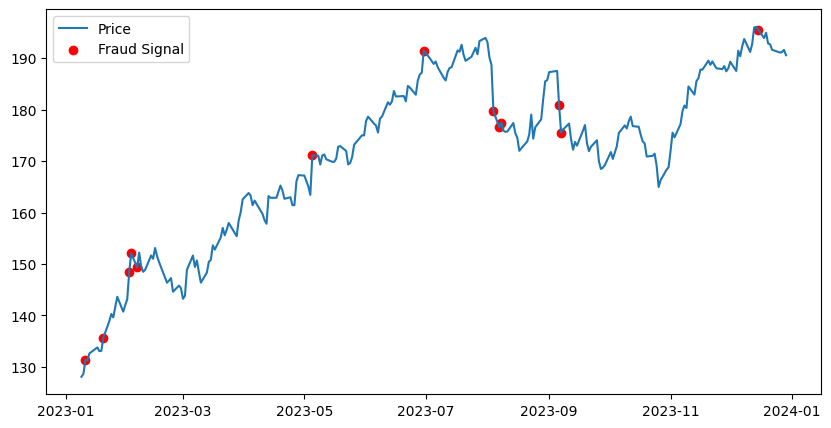

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(stock['Close'], label="Price")

# Mark anomalies
anomalies = stock[stock['Anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['Close'], color='red', label='Fraud Signal')

plt.legend()
plt.show()

In [8]:
!pip install streamlit

import streamlit as st

st.title("Quantum Fraud Detection System")

st.line_chart(stock['Close'])

st.write("Detected anomalies:")
st.write(anomalies)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 35.2 MB/s eta 0:00:00


2026-03-18 07:16:08.891 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:16:09.131 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-18 07:16:09.131 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:16:09.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:16:12.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:16:12.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:16:12.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:16:12.090 Thread 'MainThread': mi

In [9]:
# First, let's ensure the Streamlit code is in a separate .py file.
# We'll write the existing Streamlit code to a file named `app.py`.

streamlit_code = """
import streamlit as st
import pandas as pd
import yfinance as yf
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Fetch stock data (assuming stock dataframe is available globally or recreated)
# For a self-contained app, you'd fetch data here.
stock = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# Create features
stock['Returns'] = stock['Close'].pct_change()
stock['Volume_Change'] = stock['Volume'].pct_change()

# Rolling statistics
stock['Rolling_Mean'] = stock['Close'].rolling(window=5).mean()
stock['Rolling_Std'] = stock['Close'].rolling(window=5).std()

stock = stock.dropna()

# Apply IsolationForest for anomaly detection
features = stock[['Returns', 'Volume_Change', 'Rolling_Mean', 'Rolling_Std']]
model = IsolationForest(contamination=0.05)
stock['Anomaly'] = model.fit_predict(features)
anomalies = stock[stock['Anomaly'] == -1]

st.title("Quantum Fraud Detection System")

st.write("### Stock Price Trend")
st.line_chart(stock['Close'])

st.write("### Detected Anomalies")
st.write(anomalies)

# Optional: Plotting directly in Streamlit (if not using st.line_chart)
# plt.figure(figsize=(10,5))
# plt.plot(stock['Close'], label="Price")
# plt.scatter(anomalies.index, anomalies['Close'], color='red', label='Fraud Signal')
# plt.legend()
# st.pyplot(plt)
"""

with open("app.py", "w") as f:
    f.write(streamlit_code)

print("Streamlit app code saved to app.py")

Streamlit app code saved to app.py


In [10]:
try:
    from google.colab import userdata
    token_check = userdata.get('NGROK_AUTH_TOKEN')
    if token_check:
        print(f"NGROK_AUTH_TOKEN successfully retrieved from secrets. Length: {len(token_check)}")
        print("First 5 characters of token: " + token_check[:5] + "...")
    else:
        print("NGROK_AUTH_TOKEN is found but its value is empty or None.")
except Exception as e:
    print(f"Error retrieving NGROK_AUTH_TOKEN from secrets: {e}")

Error retrieving NGROK_AUTH_TOKEN from secrets: Secret NGROK_AUTH_TOKEN does not exist.


In [11]:
# Install pyngrok to manage ngrok tunnels from Python
!pip install pyngrok

In [17]:
NGROK_AUTH_TOKEN = "your_actual_token_here"